In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

data_directory = Path.cwd() / "csv_files"
dalys  = pd.read_csv(data_directory / "dalys.CSV")
deaths = pd.read_csv(data_directory / "deaths.CSV")
ylds   = pd.read_csv(data_directory / "ylds.CSV")
ylls   = pd.read_csv(data_directory / "ylls.CSV")

feature_matrix_agg = pd.read_csv('amr_feature_matrix.csv')
X_scaled_3 = np.load('amr_X_scaled.npy')

def filtered_df(df):
    return df[
        (df["metric_name"] == "Count") &
        (df["sex_name"] == "All") &
        (df["age_group_name"] == "All Ages") &
        (df["counterfactual"] == "Drug-susceptible infection") &
        (df["infectious_syndrome"] == "All infectious syndromes")
    ].copy()

f_deaths = filtered_df(deaths)
f_dalys  = filtered_df(dalys)
f_ylls   = filtered_df(ylls)
f_ylds   = filtered_df(ylds)

keys = ["location_name", "pathogen", "antibiotic_class"]

f_deaths = f_deaths[keys + ['val']].rename(columns={'val': 'deaths'})
f_dalys  = f_dalys[keys  + ['val']].rename(columns={'val': 'dalys'})
f_ylls   = f_ylls[keys   + ['val']].rename(columns={'val': 'ylls'})
f_ylds   = f_ylds[keys   + ['val']].rename(columns={'val': 'ylds'})

merged = (f_deaths
          .merge(f_dalys, on=keys, how='inner')
          .merge(f_ylls,  on=keys, how='inner')
          .merge(f_ylds,  on=keys, how='inner'))

merged_clean = merged[
    ~merged['pathogen'].str.contains('All', case=False) &
    ~merged['antibiotic_class'].str.contains('one or more', case=False)
].copy()

print("Merged shape:", merged_clean.shape)

Merged shape: (3096, 7)



Correlation matrix:
        deaths  dalys   ylls   ylds
deaths   1.000  0.995  0.995  0.849
dalys    0.995  1.000  1.000  0.851
ylls     0.995  1.000  1.000  0.849
ylds     0.849  0.851  0.849  1.000


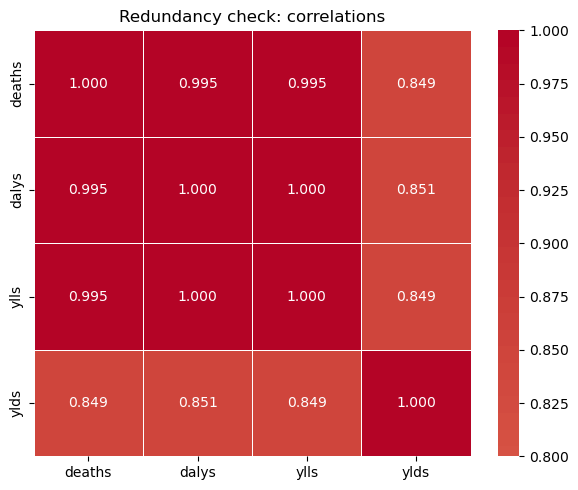

In [3]:
#correlation matrix, redundancy motivates pca:

corr = merged_clean[['deaths', 'dalys', 'ylls', 'ylds']].corr().round(3)
print("\nCorrelation matrix:")
print(corr)
 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=0.8,
            linewidths=0.5, ax=ax, fmt='.3f')
ax.set_title('Redundancy check: correlations')
plt.tight_layout()
plt.show()

In [4]:
feature_matrix = (
    merged_clean
    .groupby(['pathogen', 'antibiotic_class'])
    .agg(
        total_deaths = ('deaths', 'sum'),
        total_ylds=('ylds', 'sum'),
        total_ylls=('ylls', 'sum'),
        total_dalys=('dalys', 'sum'),
    )
    .reset_index()
)

feature_matrix[['total_deaths', 'total_ylds', 'total_ylls', 'total_dalys']] =( feature_matrix[['total_deaths', 'total_ylds', 'total_ylls', 'total_dalys']].clip(lower=0))

print("\nFeature matrix shape:", feature_matrix.shape)
print(feature_matrix.sort_values('total_deaths', ascending=False).head(5).to_string(index=False))


Feature matrix shape: (86, 6)
               pathogen                antibiotic_class  total_deaths  total_ylds   total_ylls  total_dalys
  Staphylococcus aureus                     Methicillin  46830.357949 4985.283317 1.057734e+06 1.062719e+06
       Escherichia coli                Fluoroquinolones  12833.137158 3865.011048 2.893506e+05 2.932156e+05
       Escherichia coli Third-generation cephalosporins  12545.404699 4146.879447 2.932992e+05 2.974461e+05
Acinetobacter baumannii                     Carbapenems  12324.422269  972.646257 2.941241e+05 2.950968e+05
 Pseudomonas aeruginosa                     Carbapenems  11685.306684 1578.409348 2.898538e+05 2.914322e+05


In [5]:
#center scale data
X_log = np.log1p(feature_matrix[['total_deaths', 'total_ylds', 'total_ylls', 'total_dalys']])
sc = StandardScaler()
X_scaled = sc.fit_transform(X_log)


In [6]:

#compute PCA
#covarince structure of data, decompose into eigenvectors, rank by variance
pca_corr = PCA()
X_pca_corr = pca_corr.fit_transform(X_scaled)

feature_contribution = pd.DataFrame(pca_corr.components_.T, index=['total_deaths', 'total_ylds', 'total_ylls', 'total_dalys'], columns=['PC1', 'PC2', 'PC3', 'PC4'])

#interpreting eigenvalues = amount of variance for eahc PC
explain = pca_corr.explained_variance_ratio_
print ("Variance for each components: ", explain)

print("\nHow much features contribute to each PC:")
print(feature_contribution)



Variance for each components:  [9.04367614e-01 9.02184155e-02 5.40412589e-03 9.84419008e-06]

How much features contribute to each PC:
                   PC1       PC2       PC3       PC4
total_deaths  0.517218 -0.220205  0.826805 -0.019719
total_ylds    0.443190  0.895566 -0.038541  0.007715
total_ylls    0.517512 -0.278643 -0.380924  0.713748
total_dalys   0.517929 -0.268011 -0.412073 -0.700082


Scree Plot


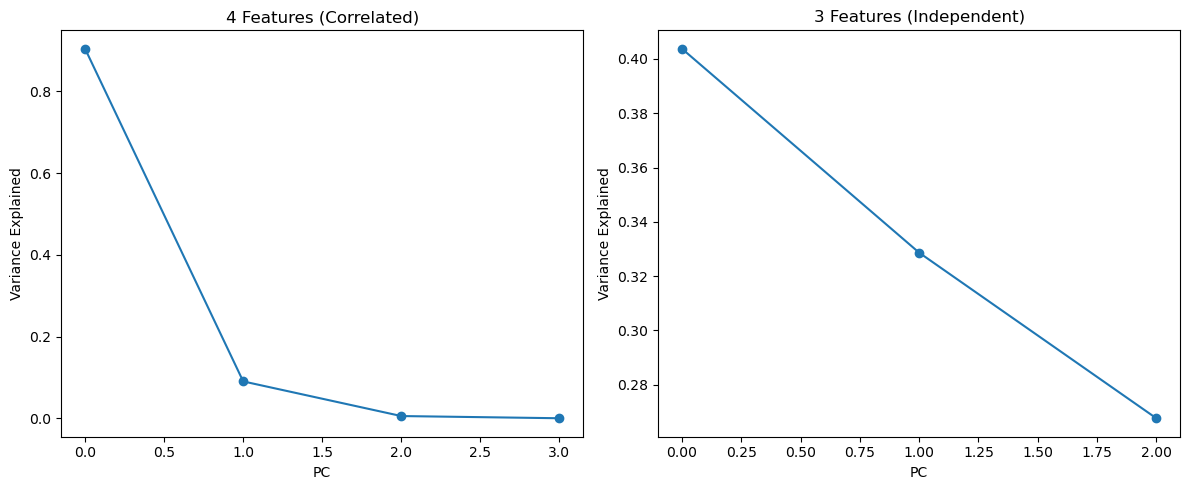


Sanity check:  PC1 = 90.4% (4 correlated features)
Independent:   PC1 = 40.4%, PC2 = 32.9% (3 features)
Variance for each component (3 features): [0.40371936 0.32862887 0.26765177]


In [7]:
pca_3 = PCA()
pca_3.fit(X_scaled_3)
X_pca_3 = pca_3.transform(X_scaled_3)

explain_3  = pca_3.explained_variance_ratio_
cumulative_3  = np.cumsum(explain_3)

print("Scree Plot")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot
axes[0].plot(explain, 'o-')
axes[0].set_title('4 Features (Correlated)')
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance Explained')

# Right plot
axes[1].plot(explain_3, 'o-')
axes[1].set_title('3 Features (Independent)')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance Explained')

plt.tight_layout()
plt.show()

print(f"\nSanity check:  PC1 = {explain[0]*100:.1f}% (4 correlated features)")
print(f"Independent:   PC1 = {explain_3[0]*100:.1f}%, PC2 = {explain_3[1]*100:.1f}% (3 features)")

print("Variance for each component (3 features):", explain_3) 


In [8]:
key_features = ['log_burden', 'mortality_prop', 'resistance_attr_frac']

loading_3 = pd.DataFrame(
    pca_3.components_.T,
    index=key_features,
    columns=['PC1', 'PC2', 'PC3']
)

print("\nLoadings (3 features):")
print(loading_3.round(4))

corr_matrix = pd.DataFrame(
    X_scaled_3,
    columns=key_features
).corr()

print("\nCorrelation matrix:")
print(corr_matrix.round(3))


Loadings (3 features):
                         PC1     PC2     PC3
log_burden            0.6849  0.1745  0.7074
mortality_prop        0.6843  0.1795 -0.7068
resistance_attr_frac -0.2503  0.9682  0.0035

Correlation matrix:
                      log_burden  mortality_prop  resistance_attr_frac
log_burden                 1.000           0.197                -0.039
mortality_prop             0.197           1.000                -0.038
resistance_attr_frac      -0.039          -0.038                 1.000


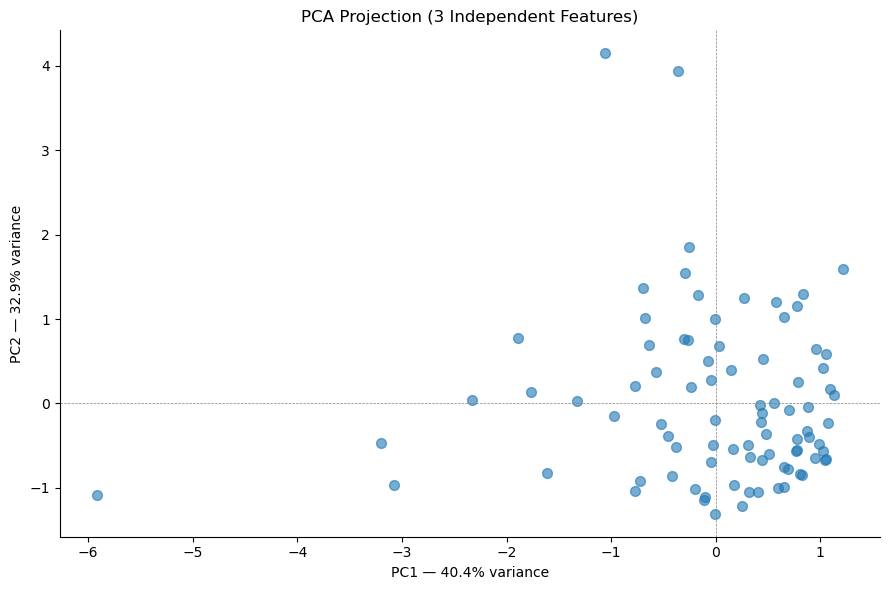

In [9]:

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    X_pca_3[:, 0],
    X_pca_3[:, 1],
    alpha=0.6,
    s=50
)

ax.set_xlabel(f"PC1 — {explain_3[0]:.1%} variance")
ax.set_ylabel(f"PC2 — {explain_3[1]:.1%} variance")
ax.set_title("PCA Projection (3 Independent Features)")

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()